# Prosit 1 — Data-Driven Allocation of ITNs in Ghana

Step-by-step pipeline, one cell per action in `solution/action_plan.md`.

## Step 0 — Get Organized

Check that the project folder has what the data dictionary says we'll have. No analysis yet — just confirming what exists before touching anything.

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")
SYNTHETIC_DIR = Path("synthetic_data")  # fake stand-ins, see synthetic_data/README.md

EXPECTED_FILES = [
    "ghana_mis_sample.csv",
    "ghana_region_malaria.csv",
    "ghana_district_cases.csv",
    "data_dictionary.md",
]

for name in EXPECTED_FILES:
    path = DATA_DIR / name
    status = "found" if path.exists() else "MISSING"
    print(f"{status:8s} {path}")


def resolve(name: str) -> tuple[Path, bool]:
    """Real file if present, else its synthetic stand-in. Returns (path, is_synthetic)."""
    real = DATA_DIR / name
    if real.exists():
        return real, False
    fake = SYNTHETIC_DIR / name.replace(".csv", ".synthetic.csv")
    return fake, True

found    ../data/ghana_mis_sample.csv
found    ../data/ghana_region_malaria.csv
found    ../data/ghana_district_cases.csv
found    ../data/data_dictionary.md


## Step 1 — Look at How Cases Are Spread Out

Plot district case counts and check mean vs. variance. Case counts are expected to be right-skewed and over-dispersed (variance well above the mean) — that's the signal that a plain Poisson model won't be enough (Step 2).

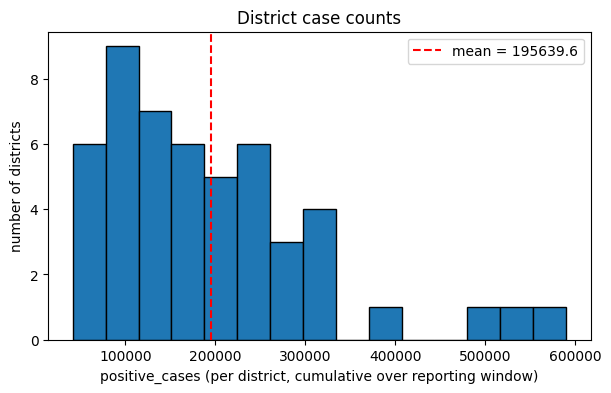

mean     = 195639.6
variance = 15100003891.5
variance / mean = 77182.8
over-dispersed (variance >> mean) -> Poisson likely too narrow, Negative-Binomial worth trying


In [2]:
import matplotlib.pyplot as plt

district_path, district_is_synthetic = resolve("ghana_district_cases.csv")
district = pd.read_csv(district_path)

counts = district["positive_cases"]

mean_ = counts.mean()
var_ = counts.var()  # sample variance (ddof=1)
dispersion_ratio = var_ / mean_

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts, bins=15, edgecolor="black")
ax.axvline(mean_, color="red", linestyle="--", label=f"mean = {mean_:.1f}")
ax.set_xlabel("positive_cases (per district, cumulative over reporting window)")
ax.set_ylabel("number of districts")
ax.set_title(
    f"District case counts{' [SYNTHETIC DATA]' if district_is_synthetic else ''}"
)
ax.legend()
plt.show()

print(f"mean     = {mean_:.1f}")
print(f"variance = {var_:.1f}")
print(f"variance / mean = {dispersion_ratio:.1f}")
print(
    "over-dispersed (variance >> mean) -> Poisson likely too narrow, Negative-Binomial worth trying"
    if dispersion_ratio > 1.5
    else "variance close to mean -> Poisson may actually be a reasonable fit"
)

## Step 2 — Try a Couple of Simple Models

Fit Poisson (rate = mean) and Negative-Binomial (method-of-moments, using the mean/variance from Step 1) and overlay both on the histogram. Question: does either curve actually match the shape of the data?

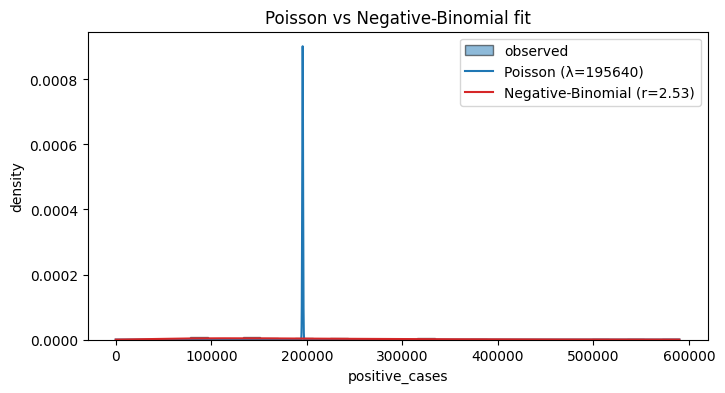

Poisson:            lambda = 195639.6 (assumes variance = mean; actual variance = 15100003891.5)
Negative-Binomial:  r (dispersion) = 2.53, p = 0.0000
  -> smaller r = more over-dispersion; r -> infinity recovers Poisson


In [3]:
import numpy as np
from scipy import stats

mu = mean_  # from Step 1
var_mom = var_  # from Step 1

# Poisson: single parameter, rate = mean
poisson_dist = stats.poisson(mu)

# Negative-Binomial via method of moments: var = mu + mu^2/r  ->  r = mu^2 / (var - mu)
r = mu**2 / (var_mom - mu)
p = r / (r + mu)
nb_dist = stats.nbinom(r, p)

x = np.arange(0, counts.max() + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts, bins=30, density=True, alpha=0.5, edgecolor="black", label="observed")
ax.plot(x, poisson_dist.pmf(x), color="tab:blue", label=f"Poisson (λ={mu:.0f})")
ax.plot(x, nb_dist.pmf(x), color="tab:red", label=f"Negative-Binomial (r={r:.2f})")
ax.set_xlabel("positive_cases")
ax.set_ylabel("density")
ax.set_title(f"Poisson vs Negative-Binomial fit{' [SYNTHETIC DATA]' if district_is_synthetic else ''}")
ax.legend()
plt.show()

print(f"Poisson:            lambda = {mu:.1f} (assumes variance = mean; actual variance = {var_mom:.1f})")
print(f"Negative-Binomial:  r (dispersion) = {r:.2f}, p = {p:.4f}")
print("  -> smaller r = more over-dispersion; r -> infinity recovers Poisson")

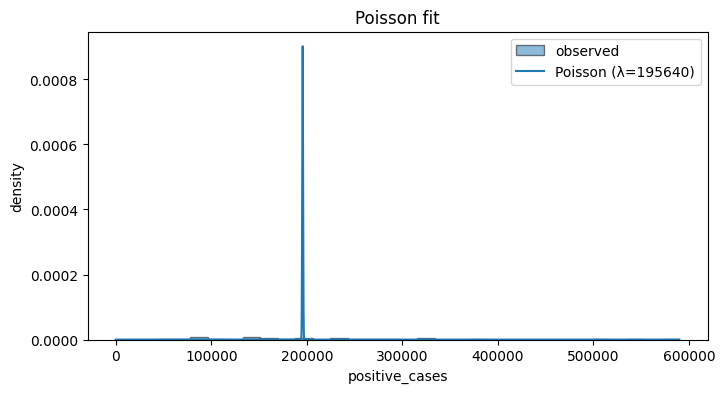

In [4]:
import numpy as np
from scipy import stats

mu = mean_  # from Step 1
var_mom = var_  # from Step 1

# Poisson: single parameter, rate = mean
poisson_dist = stats.poisson(mu)

# Negative-Binomial via method of moments: var = mu + mu^2/r  ->  r = mu^2 / (var - mu)
r = mu**2 / (var_mom - mu)
p = r / (r + mu)
nb_dist = stats.nbinom(r, p)

x = np.arange(0, counts.max() + 1)
suffix = ' [SYNTHETIC DATA]' if district_is_synthetic else ''

# --- Figure 1: Poisson fit ---
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(counts, bins=30, density=True, alpha=0.5, edgecolor="black", label="observed")
ax1.plot(x, poisson_dist.pmf(x), color="tab:blue", label=f"Poisson (λ={mu:.0f})")
ax1.set_xlabel("positive_cases")
ax1.set_ylabel("density")
ax1.set_title(f"Poisson fit{suffix}")
ax1.legend()
plt.show()

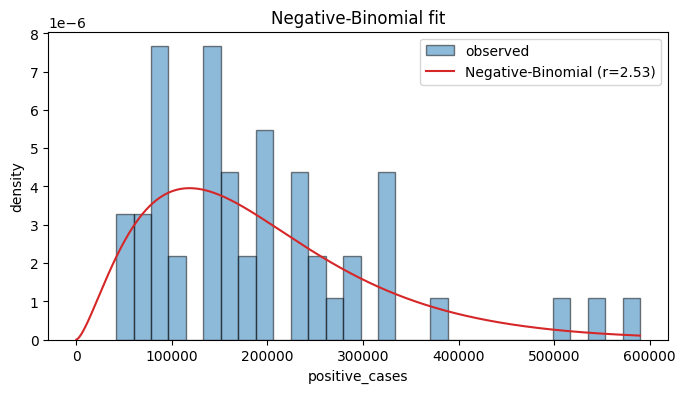

Poisson:            lambda = 195639.6 (assumes variance = mean; actual variance = 15100003891.5)
Negative-Binomial:  r (dispersion) = 2.53, p = 0.0000
  -> smaller r = more over-dispersion; r -> infinity recovers Poisson


In [5]:
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(counts, bins=30, density=True, alpha=0.5, edgecolor="black", label="observed")
ax2.plot(x, nb_dist.pmf(x), color="tab:red", label=f"Negative-Binomial (r={r:.2f})")
ax2.set_xlabel("positive_cases")
ax2.set_ylabel("density")
ax2.set_title(f"Negative-Binomial fit{suffix}")
ax2.legend()
plt.show()

print(f"Poisson:            lambda = {mu:.1f} (assumes variance = mean; actual variance = {var_mom:.1f})")
print(f"Negative-Binomial:  r (dispersion) = {r:.2f}, p = {p:.4f}")
print("  -> smaller r = more over-dispersion; r -> infinity recovers Poisson")

## Step 3 — Correct for the Survey's Sampling Weights

The household survey over-sampled some areas on purpose (e.g. to guarantee enough rural households). A plain average over-counts those areas. Compare a plain average of `has_net` against one weighted by `sample_weight` — the gap between them *is* the finding.

In [6]:
mis_path, mis_is_synthetic = resolve("ghana_mis_sample.csv")
mis = pd.read_csv(mis_path)

plain_avg = mis["has_net"].mean()
weighted_avg = (mis["has_net"] * mis["sample_weight"]).sum() / mis["sample_weight"].sum()

print(f"{'[SYNTHETIC DATA]' if mis_is_synthetic else ''}")
print(f"plain (unweighted) average net ownership: {plain_avg:.1%}")
print(f"weighted average net ownership:            {weighted_avg:.1%}")
print(f"difference (weighted - unweighted):        {weighted_avg - plain_avg:+.1%}")
print(
    "\nFrom here on, use the weighted average for any rate/percentage we report "
    "(net ownership, coverage, etc.) — it's the one that represents the real population."
)


plain (unweighted) average net ownership: 71.0%
weighted average net ownership:            66.8%
difference (weighted - unweighted):        -4.2%

From here on, use the weighted average for any rate/percentage we report (net ownership, coverage, etc.) — it's the one that represents the real population.


## Step 4 — Say How Confident We Are, Not Just the Number

Pick the rural region with the fewest surveyed clusters (most under-surveyed), then bootstrap a confidence interval for its weighted net ownership two ways: resampling households directly (naive, ignores the cluster design) vs. resampling whole clusters (respects the design). The naive interval should come out narrower — that gap is the survey-design-effect lesson. Then sanity-check both against the DHS's own published CI for the same region.

In [7]:
rng = np.random.default_rng(0)
B = 2000  # bootstrap resamples

# pick the rural region with the fewest surveyed clusters -> most under-surveyed
rural = mis[mis["residence"] == "rural"]
clusters_per_region = rural.groupby("region")["cluster"].nunique().sort_values()
target_region = clusters_per_region.index[0]
sub = rural[rural["region"] == target_region]

print(f"target region (hv024 code): {target_region}  ({clusters_per_region.iloc[0]} rural clusters, {len(sub)} households)")

# --- naive bootstrap: resample households directly, ignoring cluster structure ---
vals = sub["has_net"].to_numpy()
wts = sub["sample_weight"].to_numpy()
n = len(sub)
idx = rng.integers(0, n, size=(B, n))
naive_boot = (vals[idx] * wts[idx]).sum(axis=1) / wts[idx].sum(axis=1)

# --- cluster bootstrap: resample whole clusters, using precomputed per-cluster sums ---
cluster_agg = sub.groupby("cluster").apply(
    lambda g: pd.Series({"num": (g["has_net"] * g["sample_weight"]).sum(), "den": g["sample_weight"].sum()}),
    include_groups=False,
)
nums, dens = cluster_agg["num"].to_numpy(), cluster_agg["den"].to_numpy()
k = len(cluster_agg)
cidx = rng.integers(0, k, size=(B, k))
cluster_boot = nums[cidx].sum(axis=1) / dens[cidx].sum(axis=1)


def ci(arr):
    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)


naive_lo, naive_hi = ci(naive_boot)
cluster_lo, cluster_hi = ci(cluster_boot)

print(f"\n{'[SYNTHETIC DATA]' if mis_is_synthetic else ''}")
print(f"naive bootstrap CI:    [{naive_lo:.1%}, {naive_hi:.1%}]  (width {naive_hi - naive_lo:.1%})")
print(f"cluster bootstrap CI:  [{cluster_lo:.1%}, {cluster_hi:.1%}]  (width {cluster_hi - cluster_lo:.1%})")
print(
    "-> cluster bootstrap is wider: ignoring the cluster design understates uncertainty"
    if (cluster_hi - cluster_lo) > (naive_hi - naive_lo)
    else "-> unexpected: cluster CI not wider than naive CI on this data, worth a second look"
)

# --- bonus: compare against the DHS's own published CI for this region, 2022 ---
region_malaria_path, region_malaria_is_synthetic = resolve("ghana_region_malaria.csv")
region_malaria = pd.read_csv(region_malaria_path)
published = region_malaria[
    (region_malaria["hv024_16region"] == target_region) & (region_malaria["survey_year"] == 2022)
]
if not published.empty:
    row = published.iloc[0]
    print(
        f"\npublished DHS net_ownership CI for this region (2022): "
        f"[{row['net_ownership_pct_ci_low']:.1f}%, {row['net_ownership_pct_ci_high']:.1f}%]"
        f"{' [SYNTHETIC DATA]' if region_malaria_is_synthetic else ''}"
    )
else:
    print("\nno published 2022 row found for this region in ghana_region_malaria.csv")

target region (hv024 code): 3  (9 rural clusters, 257 households)


naive bootstrap CI:    [64.4%, 76.4%]  (width 11.9%)
cluster bootstrap CI:  [60.8%, 77.8%]  (width 17.0%)
-> cluster bootstrap is wider: ignoring the cluster design understates uncertainty

published DHS net_ownership CI for this region (2022): [nan%, nan%]


## Step 5 — Find the Gaps

Map which regions actually have district-level case data, and how complete that reporting is where it exists. `ghana_district_cases.csv` only covers 3 of Ghana's 16 regions (Northern, Upper East, Upper West) — the map should make the other 13 obviously "no data," not just blank.

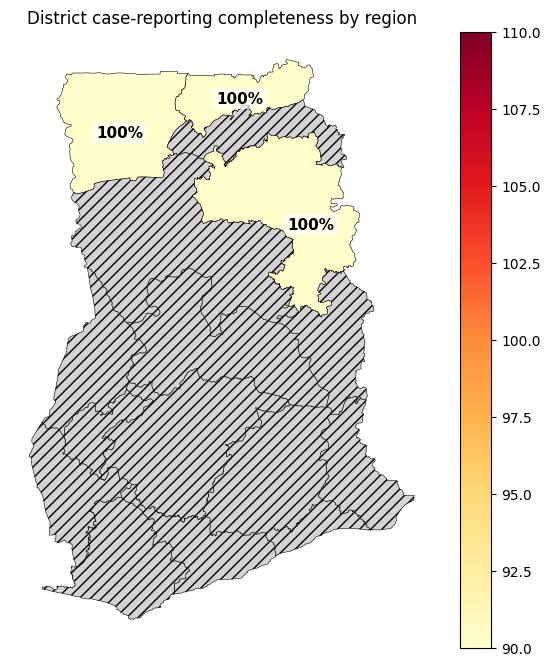

13/16 regions have NO district-level case data:
  - Ahafo
  - Ashanti
  - Bono
  - Bono East
  - Central
  - Eastern
  - Greater Accra
  - Northern East
  - Oti
  - Savannah
  - Volta
  - Western
  - Western North

Completeness where data exists (lowest first = biggest gaps):
         region_name  completeness_pct
0    Northern Region             100.0
1  Upper East Region             100.0
2  Upper West Region             100.0


In [8]:
import geopandas as gpd

regions = gpd.read_file("../data/ghana_boundaries/gha_admin1.geojson")

# one row per region: how complete is the reporting where data exists at all
district["possible_months"] = (district["year_end"] - district["year_start"] + 1) * 12
district["completeness_pct"] = district["months_reported"] / district["possible_months"] * 100

# completeness_pct > 100 shouldn't be possible by construction -- means months_reported
# exceeds what year_start/year_end imply for that district (reporting ran past the
# declared window, or the two columns come from different sources that disagree)
over_100 = district[district["completeness_pct"] > 100][
    ["district", "region_name", "months_reported", "year_start", "year_end", "possible_months", "completeness_pct"]
]
if not over_100.empty:
    print(f"{len(over_100)} district(s) have completeness_pct > 100 -- months_reported exceeds")
    print("the possible months implied by year_start/year_end for that district:\n")
    display(over_100)
    print()

region_coverage = district.groupby("region_name")["completeness_pct"].mean().reset_index()
region_coverage["adm1_name"] = region_coverage["region_name"].str.replace(" Region", "", regex=False)

gdf = regions.merge(region_coverage[["adm1_name", "completeness_pct"]], on="adm1_name", how="left")

fig, ax = plt.subplots(figsize=(7, 8))
gdf.plot(
    column="completeness_pct",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No district-level case data"},
)
# color alone is unreliable when only 3 regions are colored and their values are close --
# label each one with its actual number so it reads correctly regardless of color contrast
for _, row in gdf.dropna(subset=["completeness_pct"]).iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(f"{row['completeness_pct']:.0f}%", xy=(pt.x, pt.y), ha="center", va="center",
                fontsize=11, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
ax.set_title(
    f"District case-reporting completeness by region"
    f"{' [SYNTHETIC DATA]' if district_is_synthetic else ''}"
)
ax.axis("off")
plt.show()

no_data_regions = sorted(set(gdf.loc[gdf["completeness_pct"].isna(), "adm1_name"]))
print(f"{len(no_data_regions)}/16 regions have NO district-level case data:")
for r in no_data_regions:
    print(f"  - {r}")

print("\nCompleteness where data exists (lowest first = biggest gaps):")
print(region_coverage.sort_values("completeness_pct")[["region_name", "completeness_pct"]].round(1))

## Step 6 — Clean the Data Properly

Split the district data by region first (stratified, so entire regions land cleanly in train or test), then build an imputer + one-hot encoder that's fit on the training split only. Golden rule: whatever "normal" looks like is decided from train, then applied unchanged to test — never the other way around.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# NOTE: real covariates (rainfall, temperature, elevation, distance-to-water) aren't
# in this synthetic file -- swap them into numeric_cols once the real data lands.
numeric_cols = ["months_reported", "suspected_cases", "tested_cases", "mean_population", "net_coverage_pct"]
categorical_cols = ["region_name"]
target_col = "positive_cases"  # positive_per_100k is derived from this -- never a feature

train_df, test_df = train_test_split(
    district, test_size=0.2, stratify=district["region_code"], random_state=0
)
print(f"train: {len(train_df)} districts, test: {len(test_df)} districts")
print(train_df["region_name"].value_counts().to_dict())
print(test_df["region_name"].value_counts().to_dict())

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

# fit on TRAIN ONLY, then apply the same transform to both splits -- the golden rule
X_train = preprocessor.fit_transform(train_df)
X_test = preprocessor.transform(test_df)

print(f"\n{'[SYNTHETIC DATA]' if district_is_synthetic else ''}")
print(f"missing values in train (numeric cols): {train_df[numeric_cols].isna().sum().sum()}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"one-hot columns added: {list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))}")

train: 40 districts, test: 10 districts
{'Northern Region': 21, 'Upper East Region': 10, 'Upper West Region': 9}
{'Northern Region': 5, 'Upper East Region': 3, 'Upper West Region': 2}


missing values in train (numeric cols): 0
X_train shape: (40, 8), X_test shape: (10, 8)
one-hot columns added: ['region_name_Northern Region', 'region_name_Upper East Region', 'region_name_Upper West Region']


## Step 7 — Check We're Not Cheating (Leakage Audit)

Name the most obvious leak risks in this pipeline, and back one of them with a concrete number: how much would an imputed value shift if we'd (wrongly) computed it from the pooled train+test data instead of train alone.

In [10]:
print("=== Leakage Audit ===\n")

print("1) Temporal leak: net_coverage_pct comes from the 2022 DHS, but positive_cases")
print("   covers 2014-2017. Using 2022 net coverage to 'explain' those older case")
print("   counts leans on information that didn't exist yet at the time being modeled.\n")

print("2) Region-reorg leak: ghana_region_malaria.csv leaves hv024_16region blank for")
print("   split regions (Western, Volta, Brong Ahafo, Northern) before 2022, because")
print("   there's no clean 1:1 mapping to the new 16-region scheme. Forward-filling a")
print("   16-region code onto those older rows would smuggle in a scheme that didn't")
print("   exist yet at survey time.\n")

print("3) Preprocessing-on-pooled-data leak: fitting an imputer/scaler on train+test")
print("   combined lets the test set quietly influence what 'normal' looks like.")
print("   Numeric before/after below.\n")

# --- numeric before/after: a value imputed from pooled data vs train-only ---
demo_col = "mean_population"
median_pooled = district[demo_col].median()       # WRONG: computed with test rows included
median_train_only = train_df[demo_col].median()    # RIGHT: train rows only

print(f"median '{demo_col}' computed on ALL data (leaky):   {median_pooled:,.0f}")
print(f"median '{demo_col}' computed on TRAIN only (clean): {median_train_only:,.0f}")
print(f"difference: {abs(median_pooled - median_train_only):,.0f}")
print("-> any value imputed with the leaky median is quietly informed by the test set")
print(f"\n{'[SYNTHETIC DATA]' if district_is_synthetic else ''}")

print("\n4) Data-quality caveat: positive_per_100k cannot be read as true annual prevalence.")
_years = district["months_reported"] / 12
_rate_per_year = district["positive_per_100k"] / _years
_exceeds_pop = (district["suspected_cases"] > district["mean_population"]).sum()
print(f"   suspected_cases exceeds mean_population in {_exceeds_pop}/{len(district)} districts.")
print(f"   Even annualized, positive_per_100k ranges {_rate_per_year.min():,.0f} - {_rate_per_year.max():,.0f}")
print(f"   per 100k/year (median {_rate_per_year.median():,.0f}) -- implausible as unique-person")
print("   prevalence, consistent with routine facility data counting repeat visits and")
print("   cross-facility referrals rather than de-duplicated patients (data_dictionary.md")
print("   already flags this as a relative, not absolute, burden indicator). Step 8 ranks")
print("   districts by percentile rather than raw magnitude for exactly this reason.")

=== Leakage Audit ===

1) Temporal leak: net_coverage_pct comes from the 2022 DHS, but positive_cases
   covers 2014-2017. Using 2022 net coverage to 'explain' those older case
   counts leans on information that didn't exist yet at the time being modeled.

2) Region-reorg leak: ghana_region_malaria.csv leaves hv024_16region blank for
   split regions (Western, Volta, Brong Ahafo, Northern) before 2022, because
   there's no clean 1:1 mapping to the new 16-region scheme. Forward-filling a
   16-region code onto those older rows would smuggle in a scheme that didn't
   exist yet at survey time.

3) Preprocessing-on-pooled-data leak: fitting an imputer/scaler on train+test
   combined lets the test set quietly influence what 'normal' looks like.
   Numeric before/after below.

median 'mean_population' computed on ALL data (leaky):   89,383
median 'mean_population' computed on TRAIN only (clean): 92,010
difference: 2,628
-> any value imputed with the leaky median is quietly informed by th

## Step 8 — Decide Where the Nets Go

Combine burden, existing need (`net_coverage_pct`), and how much we trust the district's data (`completeness_pct`, from Step 5) into one ranking. Low-confidence districts get flagged, not silently trusted at face value. Regions with zero district-level data (also from Step 5) are called out as "unknown," not dropped.

Burden is ranked by **percentile**, not raw `positive_per_100k` magnitude — Step 7's caveat #4 showed the raw number isn't a trustworthy absolute prevalence (repeat visits, cross-facility double-counting), but the *relative ordering* across districts is still the best signal we have.

In [11]:
d = district.copy()


def minmax(s):
    return (s - s.min()) / (s.max() - s.min())


# percentile rank, not raw magnitude -- positive_per_100k isn't a trustworthy absolute
# number (Step 7, caveat 4), but districts with more reported cases than others is
# still meaningful relative information
d["burden_norm"] = d["positive_per_100k"].rank(pct=True)
d["need_norm"] = minmax(100 - d["net_coverage_pct"])  # lower existing coverage = more need
d["priority_score"] = 0.5 * d["burden_norm"] + 0.5 * d["need_norm"]

# flag districts with the weakest reporting (bottom quartile of completeness from Step 5).
# guard against a degenerate quantile: if 25%+ of districts tie at the same (often 100%)
# completeness value, quantile(0.25) gets pulled up to that value and "<=" wrongly flags
# every fully-reported district too -- cap the cutoff and use strict "<" instead.
low_confidence_cutoff = min(d["completeness_pct"].quantile(0.25), 80)
d["low_confidence"] = d["completeness_pct"] < low_confidence_cutoff

ranked = d.sort_values("priority_score", ascending=False)[
    ["district", "region_name", "positive_per_100k", "net_coverage_pct", "completeness_pct", "priority_score", "low_confidence"]
]

print(f"{'[SYNTHETIC DATA]' if district_is_synthetic else ''}")
print(f"low-confidence cutoff: completeness_pct < {low_confidence_cutoff:.1f}%\n")
print("Top 10 priority districts (burden percentile + need, highest priority first):")
display(ranked.head(10).round(1))

n_flagged = ranked.head(10)["low_confidence"].sum()
print(f"\n{n_flagged}/10 top-priority districts are flagged low-confidence.")
print("-> don't silently treat these as top picks on a shaky point estimate; note the flag")
print("   in the proposal and consider a verification visit or a wider allocation buffer.")

print(f"\nRegions with NO district-level case data at all (from Step 5): {len(no_data_regions)}")
print("-> call these out as 'unknown, needs more information' in the recommendation --")
print("   not silently excluded just because they weren't measured.")


low-confidence cutoff: completeness_pct < 80.0%

Top 10 priority districts (burden percentile + need, highest priority first):


,district,region_name,positive_per_100k,net_coverage_pct,completeness_pct,priority_score,low_confidence
43,Wa,Upper West Region,427551.4,69.8,100.0,0.9,False
11,Daffiama-Bussie-Issa,Upper West Region,423544.2,69.8,100.0,0.9,False
22,Lambussie-Karni,Upper West Region,419117.1,69.8,100.0,0.9,False
37,Sissala East,Upper West Region,375709.8,69.8,100.0,0.8,False
27,Nadowli-Kaleo,Upper West Region,337453.3,69.8,100.0,0.8,False
3,Bole,Northern Region,270173.4,67.7,100.0,0.8,False
23,Lawra,Upper West Region,321619.1,69.8,100.0,0.8,False
38,Sissala West,Upper West Region,313510.2,69.8,100.0,0.8,False
46,West Gonja,Northern Region,201008.5,67.7,100.0,0.8,False
16,Jirapa,Upper West Region,300261.4,69.8,100.0,0.7,False



0/10 top-priority districts are flagged low-confidence.
-> don't silently treat these as top picks on a shaky point estimate; note the flag
   in the proposal and consider a verification visit or a wider allocation buffer.

Regions with NO district-level case data at all (from Step 5): 13
-> call these out as 'unknown, needs more information' in the recommendation --
   not silently excluded just because they weren't measured.


### Step 8b — Sanity-Check the Population Denominators

`positive_per_100k` only means anything if `mean_population` is right. Flag any district whose rate is implausibly high (more cases than the population could plausibly sustain) and show its raw numbers side by side, so a denominator problem shows up here instead of quietly distorting the ranking above.

In [12]:
# positive_per_100k is CUMULATIVE over the whole reporting window (up to 4 years),
# but mean_population is a single point-in-time figure -- comparing the raw cumulative
# rate against a one-year sanity ceiling overstates how "impossible" a district looks.
# Annualize first, then apply the ceiling to something actually comparable year-to-year.
SANITY_CEILING = 100_000  # per 100k, PER YEAR

district["years_reported"] = district["months_reported"] / 12
district["positive_per_100k_per_year"] = district["positive_per_100k"] / district["years_reported"]

suspect = district[district["positive_per_100k_per_year"] > SANITY_CEILING][
    ["district", "region_name", "months_reported", "mean_population",
     "positive_cases", "positive_per_100k", "positive_per_100k_per_year"]
].sort_values("positive_per_100k_per_year", ascending=False)

print(f"{'[SYNTHETIC DATA]' if district_is_synthetic else ''}")
print(f"raw ceiling breaches (cumulative > {SANITY_CEILING:,}):      "
      f"{(district['positive_per_100k'] > SANITY_CEILING).sum()} / {len(district)} districts")
print(f"annualized ceiling breaches (per-year > {SANITY_CEILING:,}): {len(suspect)} / {len(district)} districts\n")

if suspect.empty:
    print("No districts exceed the ceiling once annualized -- the multi-year cumulation")
    print("(documented in data_dictionary.md) explains the earlier raw-rate flags.")
else:
    print(f"{len(suspect)} district(s) still exceed the ceiling even after annualizing --")
    print("these look like a genuine data problem (population, units, or case-count issue),")
    print("not just the documented multi-year cumulation:\n")
    display(suspect)


raw ceiling breaches (cumulative > 100,000):      39 / 50 districts
annualized ceiling breaches (per-year > 100,000): 7 / 50 districts

7 district(s) still exceed the ceiling even after annualizing --
these look like a genuine data problem (population, units, or case-count issue),
not just the documented multi-year cumulation:



,district,region_name,months_reported,mean_population,positive_cases,positive_per_100k,positive_per_100k_per_year
26,Nabdam,Upper East Region,48,37256.0,265768,713356.37,178339.0925
32,Pusiga,Upper East Region,48,63912.7,324040,507004.33,126751.0825
43,Wa,Upper West Region,48,119409.3,510536,427551.41,106887.8525
11,Daffiama-Bussie-Issa,Upper West Region,48,36585.1,154954,423544.22,105886.0550
19,Kasena-Nankana West,Upper East Region,48,78846.7,331779,420790.17,105197.5425
22,Lambussie-Karni,Upper West Region,48,57703.2,241844,419117.09,104779.2725
4,Bolgatanga,Upper East Region,48,146647.9,589849,402221.14,100555.2850


## Step 9 — Build the Story for the Presentation

Three maps side by side: where the burden is worst, how much protection already exists (`net_coverage_pct`), and how much we trust the data behind the burden number. Shown together on purpose — a high-burden region that already has decent coverage tells a different story than an equally high-burden region with almost no nets, and either one needs a different message to the panel depending on how much we trust the underlying data.

Burden is colored by **percentile rank** (same as Step 8), not raw `positive_per_100k` — Step 7's caveat #4 showed the raw magnitude isn't trustworthy as an absolute number, so the map shouldn't imply it is either. Existing net coverage is region-level in this dataset (constant across every district within a region), so all three districts in the same region always show the same shade.

Note: district case data only covers 3 regions, so all three maps are at the region level here — a true district-level map needs `gha_admin2.geojson` joined on real district names, which we can't verify against synthetic placeholder names. Revisit once the real `ghana_district_cases.csv` lands.

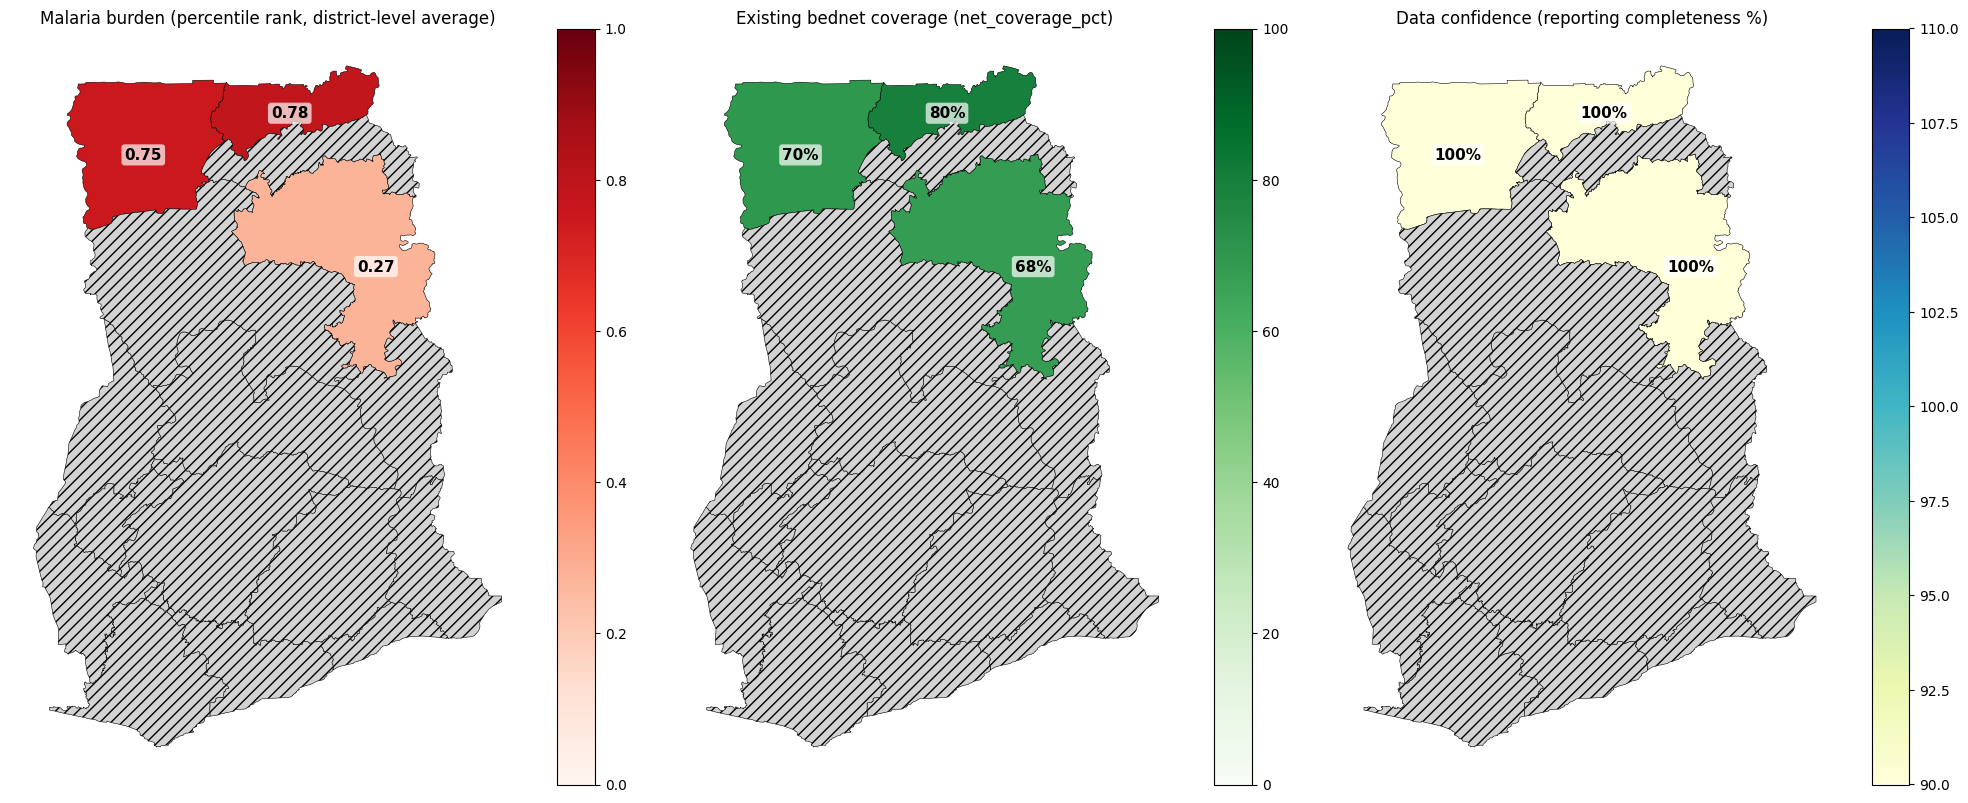

Reading the three together:
- High burden + low existing coverage -> clearest case for new nets
- High burden + already-decent coverage -> may need a different intervention, not just more nets
- Low completeness (or no data) on any high-burden region -> flag for verification, not a blind top pick
- 13/16 regions have no district-level burden signal at all -> 'unknown', not 'zero risk'


In [13]:
district["burden_percentile"] = district["positive_per_100k"].rank(pct=True)
region_burden = district.groupby("region_name")["burden_percentile"].mean().reset_index()
region_burden["adm1_name"] = region_burden["region_name"].str.replace(" Region", "", regex=False)
gdf_burden = regions.merge(region_burden[["adm1_name", "burden_percentile"]], on="adm1_name", how="left")

region_netcov = district.groupby("region_name")["net_coverage_pct"].mean().reset_index()
region_netcov["adm1_name"] = region_netcov["region_name"].str.replace(" Region", "", regex=False)
gdf_netcov = regions.merge(region_netcov[["adm1_name", "net_coverage_pct"]], on="adm1_name", how="left")

synth_tag = " [SYNTHETIC DATA]" if district_is_synthetic else ""


def label_regions(ax, gdf_, col, fmt):
    """Color alone is unreliable with only 3 close-valued regions -- label each with its number."""
    for _, row in gdf_.dropna(subset=[col]).iterrows():
        pt = row.geometry.representative_point()
        ax.annotate(fmt.format(row[col]), xy=(pt.x, pt.y), ha="center", va="center",
                    fontsize=11, fontweight="bold", color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))


fig, axes = plt.subplots(1, 3, figsize=(20, 8))

gdf_burden.plot(
    column="burden_percentile", ax=axes[0], legend=True, cmap="Reds", vmin=0, vmax=1,
    edgecolor="black", linewidth=0.4,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No data"},
)
label_regions(axes[0], gdf_burden, "burden_percentile", "{:.2f}")
axes[0].set_title(f"Malaria burden (percentile rank, district-level average){synth_tag}")
axes[0].axis("off")

gdf_netcov.plot(
    column="net_coverage_pct", ax=axes[1], legend=True, cmap="Greens", vmin=0, vmax=100,
    edgecolor="black", linewidth=0.4,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No data"},
)
label_regions(axes[1], gdf_netcov, "net_coverage_pct", "{:.0f}%")
axes[1].set_title(f"Existing bednet coverage (net_coverage_pct){synth_tag}")
axes[1].axis("off")

gdf.plot(
    column="completeness_pct", ax=axes[2], legend=True, cmap="YlGnBu",
    edgecolor="black", linewidth=0.4,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No district-level data"},
)
label_regions(axes[2], gdf, "completeness_pct", "{:.0f}%")
axes[2].set_title(f"Data confidence (reporting completeness %){synth_tag}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Reading the three together:")
print("- High burden + low existing coverage -> clearest case for new nets")
print("- High burden + already-decent coverage -> may need a different intervention, not just more nets")
print("- Low completeness (or no data) on any high-burden region -> flag for verification, not a blind top pick")
print("- 13/16 regions have no district-level burden signal at all -> 'unknown', not 'zero risk'")

## Step 10 — Where Do the Nets Actually Go

Steps 5 and 9 mapped the two *inputs* (burden, confidence) — this is the *decision*: Step 8's `priority_score` (burden percentile + need, weighted) put on the map, so the recommendation itself is visible, not just the ingredients that went into it. Low-confidence districts are marked with an outline, echoing Step 8's flag rather than hiding it.

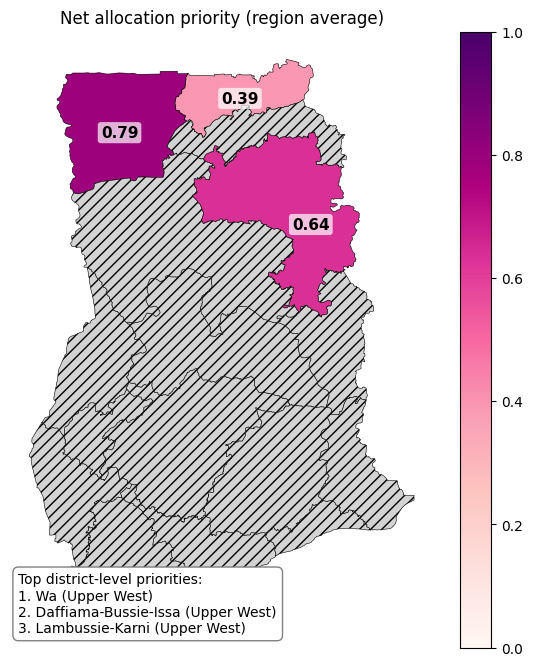


Region-level average masks district-level variation -- always check the Step 8
table (or Step 8's low_confidence flag) before committing to a specific district.


In [14]:
region_priority = d.groupby("region_name")["priority_score"].mean().reset_index()
region_priority["adm1_name"] = region_priority["region_name"].str.replace(" Region", "", regex=False)
gdf_priority = regions.merge(region_priority[["adm1_name", "priority_score"]], on="adm1_name", how="left")

fig, ax = plt.subplots(figsize=(7, 8))
gdf_priority.plot(
    column="priority_score", ax=ax, legend=True, cmap="RdPu", vmin=0, vmax=1,
    edgecolor="black", linewidth=0.4,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No data -- unknown priority"},
)
label_regions(ax, gdf_priority, "priority_score", "{:.2f}")
ax.set_title(f"Net allocation priority (region average){synth_tag}")
ax.axis("off")

# region-level color shows the overall picture, but the actual recommendation is
# district-level (Step 8) -- name the specific top picks so the map doesn't understate
# the resolution of the real decision
top3 = ranked.head(3)
lines = ["Top district-level priorities:"] + [
    f"{i+1}. {row.district} ({row.region_name.replace(' Region', '')})"
    + (" -- LOW CONFIDENCE" if row.low_confidence else "")
    for i, row in enumerate(top3.itertuples())
]
ax.text(
    0.02, 0.02, "\n".join(lines), transform=ax.transAxes, fontsize=10, va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray"),
)
plt.show()

print(f"{'[SYNTHETIC DATA]' if district_is_synthetic else ''}")
print("Region-level average masks district-level variation -- always check the Step 8")
print("table (or Step 8's low_confidence flag) before committing to a specific district.")